In [1]:
import numpyro
from numpyro import sample, deterministic, factor
from numpyro.distributions import Normal
from numpyro.handlers import seed, trace, substitute, condition
from numpyro.infer import MCMC, NUTS
from jax import random, numpy as jnp
import arviz as az
# numpyro.enable_x64()

/home/gomesu/workspace/dev_jeanspy/jeanspy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Here we define a simple model with two random variables x and y, 
# and a deterministic variable z which is the sum of x and y.
def mymodel(data=None):
    x = sample("x", Normal(0, 1))
    y = sample("y", Normal(x, 1))
    z = deterministic("z", x + y)
    val = sample("data", Normal(z,1), obs=data)  # This is an observed variable, which will be used for conditioning
    # return x, y, z

obs_data = jnp.array(1.0)

for rng_seed in range(5):
    def seeded_mymodel(data=None):
        return seed(mymodel, rng_seed=rng_seed)(data)  
    traced_model = trace(seeded_mymodel)  # NOTE: numpyro model must be wrapped with seed to be traced
    # traced_model = trace(mymodel)  # It does not work
    obs = traced_model.get_trace(data=obs_data)  # get_trace passes the same arguments as the original model, and returns a trace containing all variables in the model
    print(obs["x"]["value"], obs["y"]["value"], obs["z"]["value"], obs["data"]["value"])
    assert not obs["x"]["is_observed"]  # "x" is not observed
    assert not obs["y"]["is_observed"]  # "y" is not observed
    assert not hasattr(obs["z"], "is_observed")  # deterministic variables do not have "is_observed" attribute
    assert obs["data"]["is_observed"]  # "data" is observed
    assert obs["data"]["value"] == obs_data  # "data" has the same value as obs_data

-2.4424558 -3.6999333 -6.1423893 1.0
-0.24392003 0.7038315 0.45991147 1.0
2.6262152 3.727943 6.3541584 1.0
-1.9432216 -2.2451057 -4.1883273 1.0
0.3526764 -0.34113324 0.011543155 1.0


In [3]:
# How about substituting values for x?
for rng_seed in range(5):
    seeded_mymodel = seed(mymodel, rng_seed=rng_seed)  # Seed the model for reproducibility
    substituted_model = substitute(seeded_mymodel, data={"x": 1.0})
    traced_substituted_model = trace(substituted_model)
    obs = traced_substituted_model.get_trace(data=obs_data)
    assert obs["x"]["value"] == 1.0  # "x" is substituted with 1.0
    assert not obs["x"]["is_observed"]  # "x" is not observed, it's substituted
    assert not obs["y"]["is_observed"]  # "y" is not observed
    assert not hasattr(obs["z"], "is_observed")  # deterministic variables do not have "is_observed" attribute
    assert obs["data"]["is_observed"]  # "data" is observed
    print(obs["x"]["value"], obs["y"]["value"], obs["z"]["value"], obs["data"]["value"])

1.0 -0.25747752 0.7425225 1.0
1.0 1.9477515 2.9477515 1.0
1.0 2.101728 3.101728 1.0
1.0 0.69811594 1.698116 1.0
1.0 0.30619037 1.3061904 1.0


In [4]:
# How about substituting values for x and y?
for rng_seed in range(5):
    seeded_mymodel = seed(mymodel, rng_seed=rng_seed)  # Seed the model for reproducibility
    substituted_model = substitute(seeded_mymodel, data={"x": 1.0, "y": 2.0})
    traced_substituted_model = trace(substituted_model)
    obs = traced_substituted_model.get_trace(data=obs_data)
    print(obs["x"]["value"], obs["y"]["value"], obs["z"]["value"], obs["data"]["value"])

1.0 2.0 3.0 1.0
1.0 2.0 3.0 1.0
1.0 2.0 3.0 1.0
1.0 2.0 3.0 1.0
1.0 2.0 3.0 1.0


In [5]:
# is it possible to substitute value for z? This is a derived variable....
for rng_seed in range(5):
    seeded_mymodel = seed(mymodel, rng_seed=rng_seed)  # Seed the model for reproducibility
    substituted_model = substitute(seeded_mymodel, data={"z": 3.0})
    traced_substituted_model = trace(substituted_model)
    obs = traced_substituted_model.get_trace()
    print(obs["x"]["value"], obs["y"]["value"], obs["z"]["value"])
    assert not obs["x"]["value"] + obs["y"]["value"] == obs["z"]["value"]
    # actually, x + y != z in this case. numpyro traces the model in a single pass, 
    # so when it encounters the deterministic variable z, 
    # it computes it as x + y using the current values of x and y, which are not yet substituted. 
    # Therefore, substituting z does not affect the values of x and y, and the assertion will fail.
    assert not obs["x"]["is_observed"]  # "x" is not observed, it's substituted
    assert not obs["y"]["is_observed"]  # "y" is not observed
    assert not hasattr(obs["z"], "is_observed")  # deterministic variables do not have "is_observed" attribute
    assert obs["z"]["value"] == 3.0  # "z" is substituted with 3.0
    

-2.4424558 -3.6999333 3.0
-0.24392003 0.7038315 3.0
2.6262152 3.727943 3.0
-1.9432216 -2.2451057 3.0
0.3526764 -0.34113324 3.0


In [6]:
# is it possible to condition on x?
for rng_seed in range(5):
    seeded_mymodel = seed(mymodel, rng_seed=rng_seed)  # Seed the model for reproducibility
    conditioned_model = condition(seeded_mymodel, data={"x": 1.0})
    traced_conditioned_model = trace(conditioned_model)
    obs = traced_conditioned_model.get_trace(data=obs_data)
    print(obs["x"]["value"], obs["y"]["value"], obs["z"]["value"], obs["data"]["value"])
    assert obs["x"]["value"] + obs["y"]["value"] == obs["z"]["value"]
    assert obs["x"]["is_observed"]  # "x" is observed, it's conditioned
    assert not obs["y"]["is_observed"]  # "y" is not observed
    assert not hasattr(obs["z"], "is_observed")  # deterministic variables do not have "is_observed" attribute

    

1.0 -0.25747752 0.7425225 1.0
1.0 1.9477515 2.9477515 1.0
1.0 2.101728 3.101728 1.0
1.0 0.69811594 1.698116 1.0
1.0 0.30619037 1.3061904 1.0


In [7]:
# How about two factors?
def model_with_multiple_factors(data=None):
    prior_x = Normal(0, 1)
    x = sample("x", prior_x)
    prior_y = Normal(x,1)
    y = sample("y", prior_y)
    deterministic("lnp_x",prior_x.log_prob(x))
    deterministic("lnp_y",prior_y.log_prob(y))
    z = deterministic("z", x + y)
    logp1 = Normal(z, 1).log_prob(data).sum()
    logp2 = Normal(x, 1).log_prob(x).sum()  # This is just an example, it does not make much sense to have this factor in the model.
    numpyro.factor("lik1", logp1)
    numpyro.factor("lik2", logp2)
    deterministic("loglik1", logp1)  # monitor the log-likelihood for diagnostics and model comparison. This is optional, but can be useful.
    deterministic("loglik2", logp2)  # monitor the log-likelihood for diagnostics and model comparison. This is optional, but can be useful.

sampler = NUTS(model_with_multiple_factors)
mcmc = MCMC(sampler, num_warmup=100, num_samples=1000, num_chains=2,jit_model_args=True)
mcmc.run(
    random.PRNGKey(0), 
    data=obs_data,
    extra_fields=["potential_energy"])
idata = az.from_numpyro(mcmc)
idata

/tmp/ipykernel_544205/1253156157.py:18: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(sampler, num_warmup=100, num_samples=1000, num_chains=2,jit_model_args=True)
sample: 100%|██████████| 1100/1100 [00:02<00:00, 468.73it/s, 3 steps of size 5.18e-01. acc. prob=0.97]


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 2, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 16B 0 1
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           lnp_x    (chain, draw) float32 8kB -0.9719 -1.057 -1.262 ... -0.9203 -0.9483
│           lnp_y    (chain, draw) float32 8kB -1.225 -1.307 -1.514 ... -1.03 -1.106
│           loglik1  (chain, draw) float32 8kB -1.297 -1.603 -2.144 ... -1.119 -1.3
│           loglik2  (chain, draw) float32 8kB -0.9189 -0.9189 ... -0.9189 -0.9189
│           x        (chain, draw) float32 8kB -0.3254 -0.5251 ... -0.05171 -0.2424
│           y        (chain, draw) float32 8kB 0.4564 0.3557 0.2628 ... 0.4195 0.3697
│           z        (chain, draw) float32 8kB 0.131 -0.1694 -0.5651 ... 0.3678 0.1273
│       Attributes:
│           created_at:                 2026-03-12T06:28:20.296082+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /sample_stats
│       Dimensions:    (chain: 2, draw: 1000)
│       Coordinates:
│         * chain      (chain) int64 16B 0 1
│         * draw       (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           diverging  (chain, draw) bool 2kB ...
│           lp         (chain, draw) float32 8kB ...
│       Attributes:
│           created_at:                 2026-03-12T06:28:20.317203+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /observed_data
        Dimensions:     (lik1_dim_0: 0, lik2_dim_0: 0)
        Coordinates:
          * lik1_dim_0  (lik1_dim_0) int64 0B 
          * lik2_dim_0  (lik2_dim_0) int64 0B 
        Data variables:
            lik1        (lik1_dim_0) float32 0B ...
            lik2        (lik2_dim_0) float32 0B ...
        Attributes:
            created_at:                 2026-03-12T06:28:20.318702+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

[[[-1.2965462  -1.6026567  -2.143697   ... -1.5049297  -0.93501985
   -0.94611186]
  [-0.9232394  -1.2700918  -0.9245844  ... -1.446615   -1.1187935
   -1.2997532 ]]

 [[-0.9189385  -0.9189385  -0.9189385  ... -0.9189385  -0.9189385
   -0.9189385 ]
  [-0.9189385  -0.9189385  -0.9189385  ... -0.9189385  -0.9189385
   -0.9189385 ]]

 [[-0.97189474 -1.0567853  -1.2616656  ... -1.1440413  -0.9770733
   -0.95342153]
  [-1.2182767  -1.0049248  -0.9256902  ... -0.96525323 -0.92027533
   -0.9483162 ]]

 [[-1.224585   -1.3068043  -1.5138061  ... -1.193208   -1.0426283
   -1.169497  ]
  [-1.0223317  -1.41033    -1.1376169  ... -1.0879503  -1.0299479
   -1.1062573 ]]

 [[ 4.4119644   4.8851852   5.838107   ...  4.7611175   3.87366
    3.987969  ]
  [ 4.0827866   4.6042852   3.9068298  ...  4.418757    3.987955
    4.2732654 ]]] (5, 2, 1000)
[[ 0.0000000e+00  4.7683716e-07  0.0000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00 -2.3841858e-07 ...  0.00000

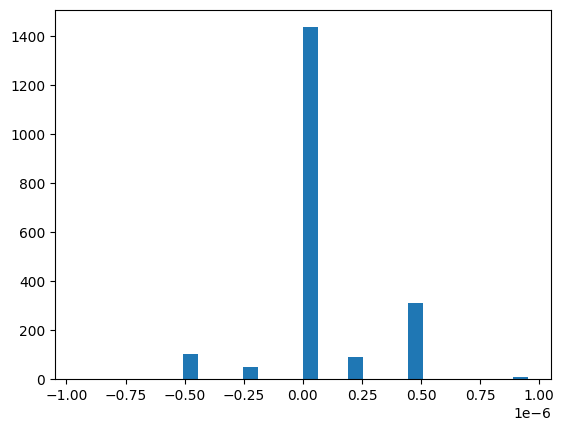

In [10]:
import matplotlib.pyplot as plt

ret = jnp.array([
    idata.posterior["loglik1"].values,
    idata.posterior["loglik2"].values,
    idata.posterior["lnp_x"].values,
    idata.posterior["lnp_y"].values,
    idata.sample_stats["lp"].values,
])
print(ret,ret.shape)
print(jnp.sum(ret,axis=0))
plt.hist(jnp.sum(ret,axis=0).flatten(), bins=30)
assert jnp.allclose(jnp.sum(ret,axis=0), 0, rtol=1e-6, atol=1e-6)  # The sum of all log-likelihoods and log-priors should be equal to the total log-probability of the model, which is stored in sample_stats["lp"].

/tmp/ipykernel_544205/1194104276.py:12: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(sampler, num_warmup=100, num_samples=1000, num_chains=2,jit_model_args=True)
sample: 100%|██████████| 1100/1100 [00:01<00:00, 699.90it/s, 1 steps of size 6.52e-01. acc. prob=0.93]


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 2, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 16B 0 1
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           mu       (chain, draw) float32 8kB 2.982 2.975 2.984 ... 2.978 2.978 2.976
│       Attributes:
│           created_at:                 2026-03-12T06:32:59.893120+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
├── Group: /sample_stats
│       Dimensions:    (chain: 2, draw: 1000)
│       Coordinates:
│         * chain      (chain) int64 16B 0 1
│         * draw       (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           diverging  (chain, draw) bool 2kB ...
│       Attributes:
│           created_at:                 2026-03-12T06:32:59.894453+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.20.0
└── Group: /observed_data
        Dimensions:                (x_dim_0: 100, additional_term_dim_0: 0)
        Coordinates:
          * x_dim_0                (x_dim_0) int64 800B 0 1 2 3 4 5 ... 95 96 97 98 99
          * additional_term_dim_0  (additional_term_dim_0) int64 0B 
        Data variables:
            x                      (x_dim_0) float32 400B ...
            additional_term        (additional_term_dim_0) float32 0B ...
        Attributes:
            created_at:                 2026-03-12T06:32:59.895427+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.20.0

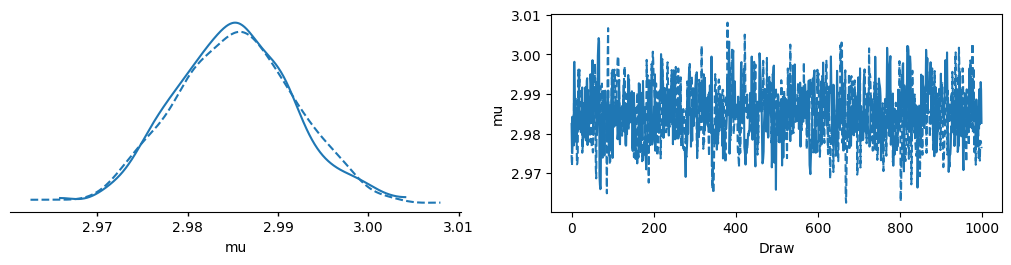

In [22]:
# What happens if both of factors and sample in in the definition of a model?

def complicated_model(data=None):
    mu = sample("mu", Normal(0, 1))  # prior for mu
    # factor("additional_term", -10000*(mu-3)**2)  # Does the factor effect the output of MCMC?
    x = sample("x", Normal(mu, 1), obs=data)
    factor("additional_term", -10000*(mu-3)**2)  # Does the factor effect the output of MCMC?
    
obs_data = Normal(0, 1).sample(random.PRNGKey(0), (100,))  # generate some mock data

sampler = NUTS(complicated_model)
mcmc = MCMC(sampler, num_warmup=100, num_samples=1000, num_chains=2,jit_model_args=True)
mcmc.run(rng_key=random.PRNGKey(0), data=obs_data)
res = az.from_numpyro(mcmc)
display(res)
az.plot_trace_dist(res)
# run mcmc and check the log-probability